In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
import os
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pillow_heif
import cv2

In [4]:
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [5]:
dataset_path = "./dataset/daun-harumanis-kagle"

In [6]:
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    class_mode='categorical',
    subset='validation'
)

Found 599 images belonging to 4 classes.
Found 147 images belonging to 4 classes.


# EDA

### Dataset Composition Analysis

In [7]:
classes = [cls for cls in os.listdir(dataset_path) 
           if os.path.isdir(os.path.join(dataset_path, cls))]

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 4
Classes: ['Anthracnose', 'Black Soothy Mold', 'healthy', 'resized_dataset']


In [8]:
total_images = 0
print("\nImages per class:")

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    num_images = len(os.listdir(class_path))
    total_images += num_images
    print(f"{cls}: {num_images}")


Images per class:
Anthracnose: 182
Black Soothy Mold: 58
healthy: 133
resized_dataset: 4


In [9]:
print("\nTotal number of images in dataset:", total_images)


Total number of images in dataset: 377


### Class distribution

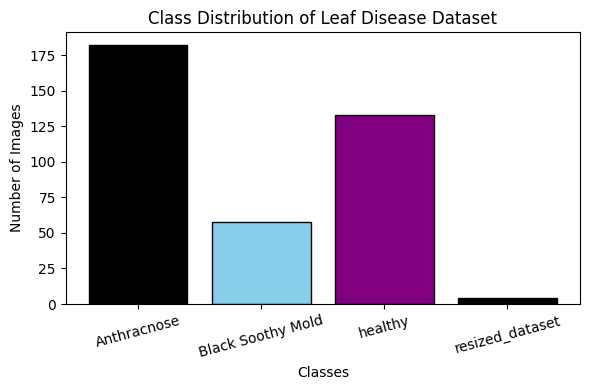

In [10]:
classes = []
image_counts = []

# Count images per class
for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    if os.path.isdir(class_path):
        classes.append(cls)
        image_counts.append(len(os.listdir(class_path)))

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(classes, image_counts, color = ['black', 'skyblue', 'purple'],edgecolor='black')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Leaf Disease Dataset")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Image Visualization

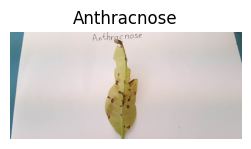

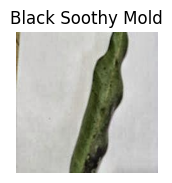

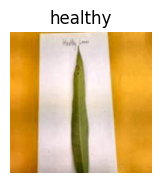

In [12]:
classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(class_path)[0]   # take first image
    img_path = os.path.join(class_path, img_name)

    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f))]
    if not image_files:
        continue

    img_path = os.path.join(class_path, image_files[0])
    img = load_img(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

<Figure size 1000x400 with 0 Axes>

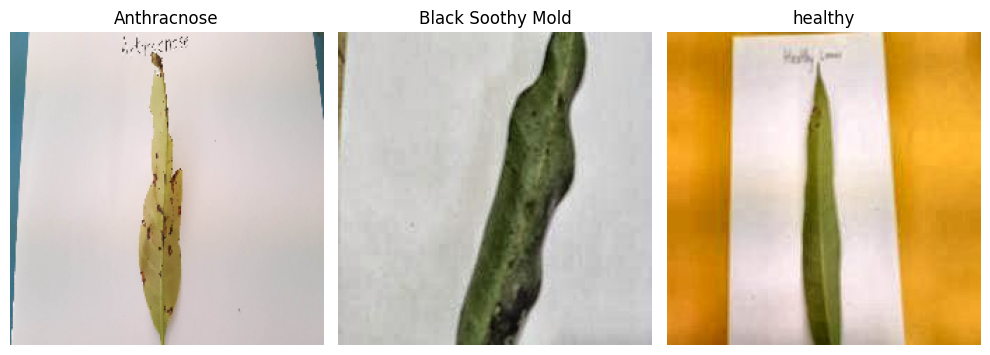

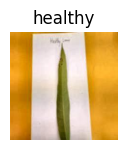

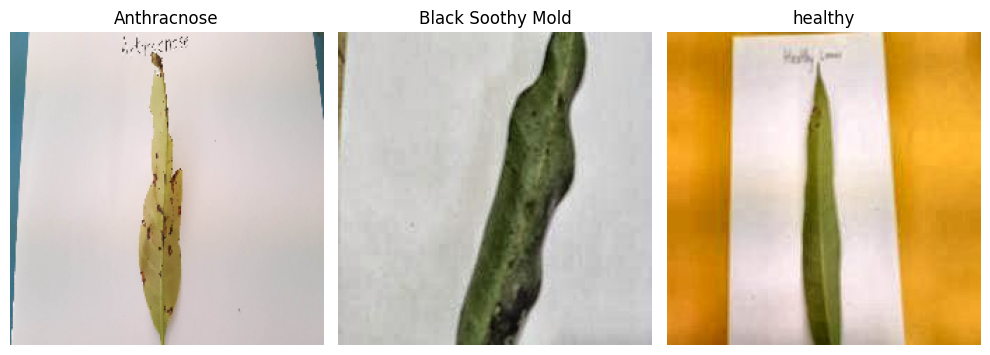

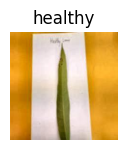

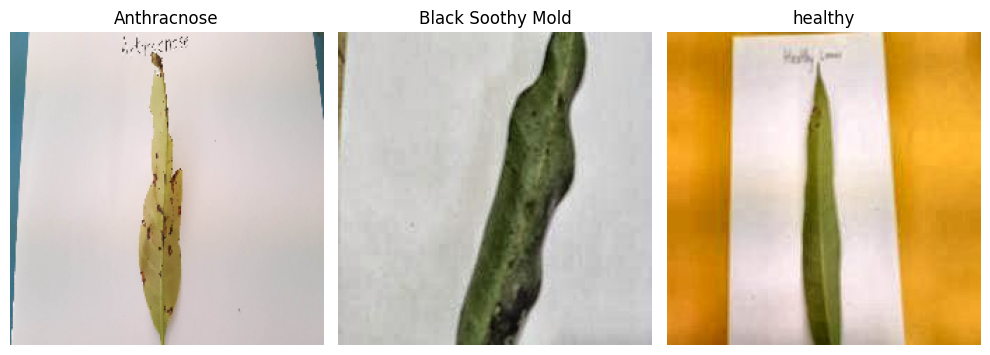

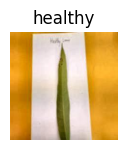

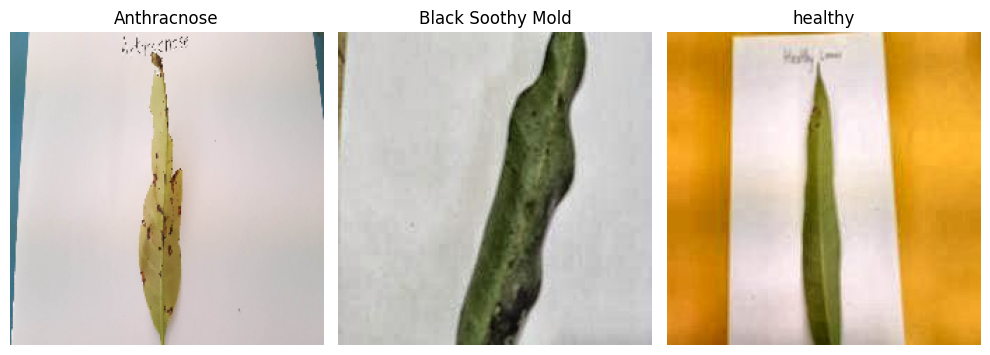

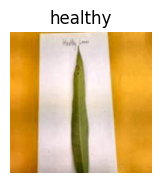

In [14]:
classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(class_path)[0]   # take first image
    img_path = os.path.join(class_path, img_name)

    classes = [cls for cls in os.listdir(dataset_path)
               if os.path.isdir(os.path.join(dataset_path, cls))]

    plt.figure(figsize=(10,4))

    valid_classes = []

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)

        image_files = [f for f in os.listdir(class_path)
                       if os.path.isfile(os.path.join(class_path, f))]
        if not image_files:
            continue

        valid_classes.append((cls, os.path.join(class_path, image_files[0])))

    for i, (cls, img_path) in enumerate(valid_classes):
        img = load_img(img_path, target_size=(224, 224))

        plt.subplot(1, len(valid_classes), i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Image resolution & shape Analysis

In [15]:
# Enable HEIC support if available
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

image_info = []

# Loop through dataset
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_info.append([cls, img_name, width, height])
            except:
                continue

# Create DataFrame
df = pd.DataFrame(image_info, columns=["Class", "Image Name", "Width", "Height"])

# Show first few rows
df.head()


,Class,Image Name,Width,Height
0,Anthracnose,anthracnose-0007.jpg,2048,946
1,Anthracnose,anthracnose-0010.jpg,2048,946
2,Anthracnose,anthracnose-0011.jpg,2048,946
3,Anthracnose,anthracnose-0020.jpg,2048,946
4,Anthracnose,anthracnose-0027.jpg,2048,946


### Data Quality Analysis

In [16]:
pillow_heif.register_heif_opener()

for img_name in os.listdir(dataset_path):
    if img_name.lower().endswith(".heic"):
        img_path = os.path.join(dataset_path, img_name)
        img = Image.open(img_path)
        new_name = img_name.replace(".heic", ".jpg")
        img.save(os.path.join(dataset_path, new_name), "JPEG")

In [17]:
corrupted_images = []
for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()   # check image integrity
            except:
                corrupted_images.append(img_path)

if len(corrupted_images) == 0:
    print("No corrupted images found. Dataset quality is good.")
else:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)

Corrupted images found:
./dataset/daun-harumanis-kagle\resized_dataset\Anthracnose
./dataset/daun-harumanis-kagle\resized_dataset\Black Soothy Mold
./dataset/daun-harumanis-kagle\resized_dataset\healthy
./dataset/daun-harumanis-kagle\resized_dataset\resized_dataset


### Visualize Sample Images from Each Disease Class

In [18]:
# Register HEIC support (safe even if no HEIC)
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

In [19]:
# Choose one class folder
class_folder = os.path.join(dataset_path, os.listdir(dataset_path)[0])

# Pick a real image automatically
image_file = random.choice(os.listdir(class_folder))
image_path = os.path.join(class_folder, image_file)

# Load image
img = Image.open(image_path).resize((224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

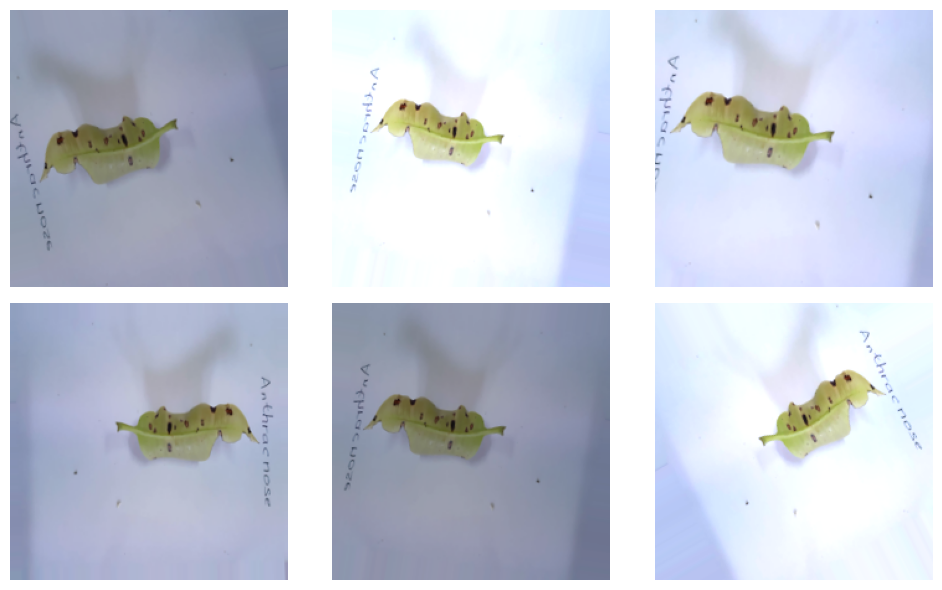

In [20]:
# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Show augmented images
plt.figure(figsize=(10, 6))
for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    if i == 5:
        break

plt.tight_layout()
plt.show()

# PRE PROCESSING

### Image Resizing

In [21]:
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

# Original dataset path
input_path = "./dataset/daun-harumanis-kagle"

# Output path for resized images
output_path = "./dataset/daun-harumanis-kagle/resized_dataset"

# Target image size
TARGET_SIZE = (224, 224)

# Create output directory
os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(input_path):
    cls_input = os.path.join(input_path, cls)
    cls_output = os.path.join(output_path, cls)
    
    if not os.path.isdir(cls_input):
        continue
    
    os.makedirs(cls_output, exist_ok=True)
    
    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(TARGET_SIZE)
            
            save_name = os.path.splitext(img_name)[0] + ".jpg"
            img.save(os.path.join(cls_output, save_name), "JPEG")
        
        except:
            continue

print("✅ Image resizing completed successfully!")


✅ Image resizing completed successfully!


### Image resolution & shape Analysis after resizing

In [22]:
# Enable HEIC support if available
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

image_info = []

# Loop through dataset
for cls in os.listdir(output_path):
    cls_path = os.path.join(output_path, cls)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_info.append([cls, img_name, width, height])
            except:
                continue

# Create DataFrame
df = pd.DataFrame(image_info, columns=["Class", "Image Name", "Width", "Height"])

# Show first few rows
df.head()


,Class,Image Name,Width,Height
0,Anthracnose,anthracnose-0007.jpg,224,224
1,Anthracnose,anthracnose-0010.jpg,224,224
2,Anthracnose,anthracnose-0011.jpg,224,224
3,Anthracnose,anthracnose-0020.jpg,224,224
4,Anthracnose,anthracnose-0027.jpg,224,224


### Image Visualization after resizing

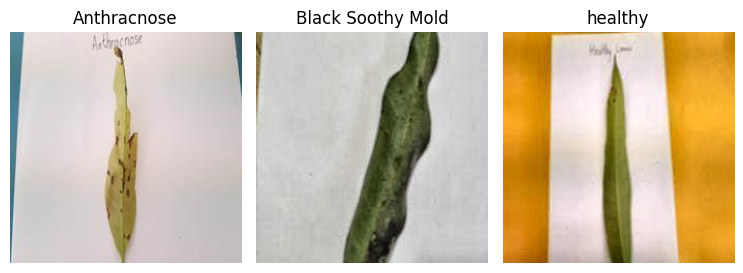

In [23]:
classes = [cls for cls in os.listdir(output_path)
           if os.path.isdir(os.path.join(output_path, cls))]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    class_path = os.path.join(output_path, cls)
    images = os.listdir(class_path)
    if len(images) == 0:
        continue
    img_name = images[0]   # take first image
    img_path = os.path.join(class_path, img_name)

    img = load_img(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Noise removal (Gaussian / Median)

In [24]:
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

# Input path (use resized RGB dataset)
input_path = "./dataset/daun-harumanis-kagle/resized_dataset"

# Output path for noise-removed images
output_path = "./dataset/daun-harumanis-kagle/denoised_dataset"

os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(input_path):
    cls_input = os.path.join(input_path, cls)
    cls_output = os.path.join(output_path, cls)
    
    if not os.path.isdir(cls_input):
        continue
    
    os.makedirs(cls_output, exist_ok=True)
    
    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)
        
        try:
            # Load image
            img = Image.open(img_path).convert("RGB")
            img_np = np.array(img)
            
            # Noise removal
            denoised = cv2.GaussianBlur(img_np, (3, 3), 0)
            #denoised = cv2.medianBlur(gaussian, 3)
            
            # Save denoised image
            Image.fromarray(denoised).save(os.path.join(cls_output, img_name))
        
        except:
            continue

print("✅ Noise removal completed successfully!")

✅ Noise removal completed successfully!


denoised_dataset

Skipping empty or non-image folder: resized_dataset


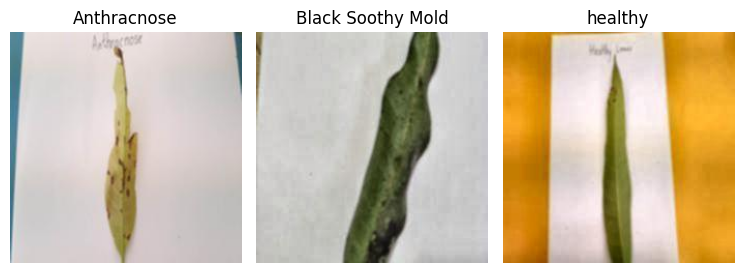

In [26]:
classes = [cls for cls in os.listdir(output_path)
           if os.path.isdir(os.path.join(output_path, cls))]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    class_path = os.path.join(output_path, cls)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not image_files:
        print(f"Skipping empty or non-image folder: {cls}")
        continue
    img_name = image_files[0]   # take first image
    img_path = os.path.join(class_path, img_name)

    img = load_img(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Image enhancement

In [27]:
import os
import cv2
import numpy as np
from PIL import Image

# Enable HEIC support if available
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

# Input path (use resized or denoised dataset)
input_path = "./dataset/daun-harumanis-kagle/denoised_dataset"

# Output path for enhanced images
output_path = "./dataset/daun-harumanis-kagle/enhanced_dataset"

os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(input_path):
    cls_input = os.path.join(input_path, cls)
    cls_output = os.path.join(output_path, cls)
    
    if not os.path.isdir(cls_input):
        continue
    
    os.makedirs(cls_output, exist_ok=True)
    
    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)
        
        try:
            # Load image
            img = Image.open(img_path).convert("RGB")
            img_np = np.array(img)
            
            # Convert RGB → LAB
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            
            # Apply CLAHE on L-channel
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l_enhanced = clahe.apply(l)
            
            # Merge channels and convert back to RGB
            lab_enhanced = cv2.merge((l_enhanced, a, b))
            enhanced_img = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
            
            # Save enhanced image
            Image.fromarray(enhanced_img).save(os.path.join(cls_output, img_name))
        
        except:
            continue

print("✅ Image enhancement completed successfully!")


✅ Image enhancement completed successfully!


enhanced_dataset

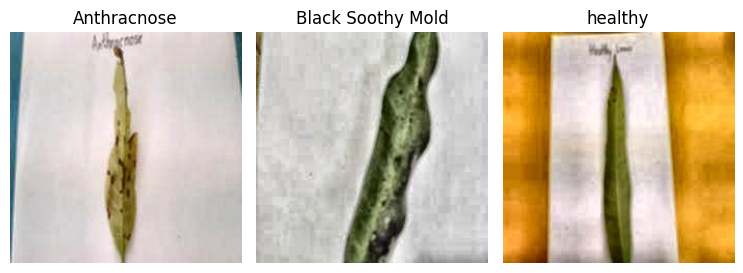

In [29]:
classes = [cls for cls in os.listdir(output_path)
           if os.path.isdir(os.path.join(output_path, cls))]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    class_path = os.path.join(output_path, cls)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f))
                   and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not image_files:
        continue
    img_name = image_files[0]
    img_path = os.path.join(class_path, img_name)

    img = load_img(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

 ### Converting to grayscale

In [30]:
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

# Input dataset path (resized images recommended)
input_path = "./dataset/daun-harumanis-kagle/enhanced_dataset"

# Output paths
gray_path = "./dataset/daun-harumanis-kagle/grayscale_dataset"
hsv_path  = "./dataset/daun-harumanis-kagle/hsv_dataset"

os.makedirs(gray_path, exist_ok=True)
os.makedirs(hsv_path, exist_ok=True)

for cls in os.listdir(input_path):
    cls_input = os.path.join(input_path, cls)
    
    if not os.path.isdir(cls_input):
        continue
    
    os.makedirs(os.path.join(gray_path, cls), exist_ok=True)
    os.makedirs(os.path.join(hsv_path, cls), exist_ok=True)
    
    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img_np = np.array(img)
            
            # Convert to Grayscale
            gray_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            
            # Convert to HSV
            hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
            
            # Save images
            Image.fromarray(gray_img).save(os.path.join(gray_path, cls, img_name))
            Image.fromarray(hsv_img).save(os.path.join(hsv_path, cls, img_name))
        
        except:
            continue

print("✅ Color space conversion completed successfully!")


✅ Color space conversion completed successfully!


### Image Visualization after gray scale conversion

Skipping empty folder: resized_dataset


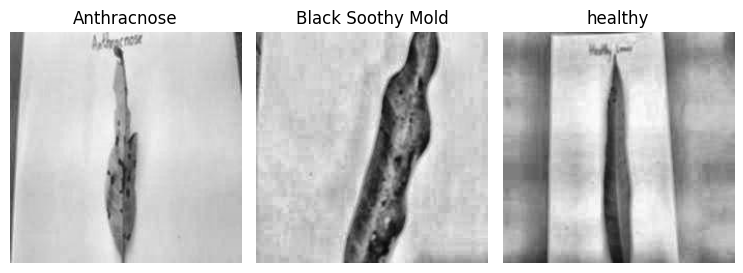

In [31]:
classes = [cls for cls in os.listdir(gray_path)
           if os.path.isdir(os.path.join(gray_path, cls))]

plt.figure(figsize=(10, 4))

plot_index = 1

for cls in classes:
    class_path = os.path.join(gray_path, cls)
    images = os.listdir(class_path)

    if len(images) == 0:
        print(f"Skipping empty folder: {cls}")
        continue

    img_path = os.path.join(class_path, images[0])  # first image
    img = load_img(img_path)

    plt.subplot(1, len(classes), plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

    plot_index += 1

plt.tight_layout()
plt.show()


### Image Visualization after hsv

Skipping empty folder: resized_dataset


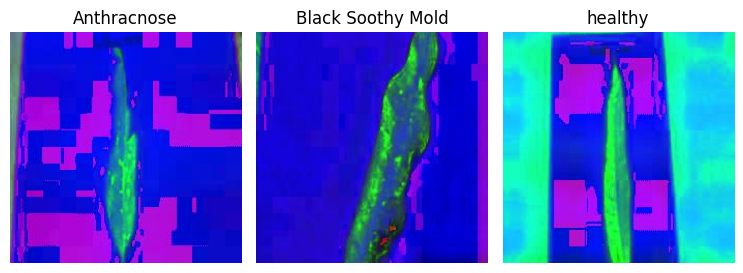

In [32]:
classes = [cls for cls in os.listdir(hsv_path)
           if os.path.isdir(os.path.join(hsv_path, cls))]

plt.figure(figsize=(10, 4))

plot_index = 1

for cls in classes:
    class_path = os.path.join(hsv_path, cls)
    images = os.listdir(class_path)

    if len(images) == 0:
        print(f"Skipping empty folder: {cls}")
        continue

    img_path = os.path.join(class_path, images[0])  # first image
    img = load_img(img_path)

    plt.subplot(1, len(classes), plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

    plot_index += 1

plt.tight_layout()
plt.show()


### Data Augmentation

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


dataset_path = "./dataset/daun-harumanis-kagle/enhanced_dataset"

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data generator (NO augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("✅ Data Augmentation setup completed successfully!")


Found 300 images belonging to 4 classes.
Found 73 images belonging to 4 classes.
✅ Data Augmentation setup completed successfully!


Skipping empty folder: resized_dataset


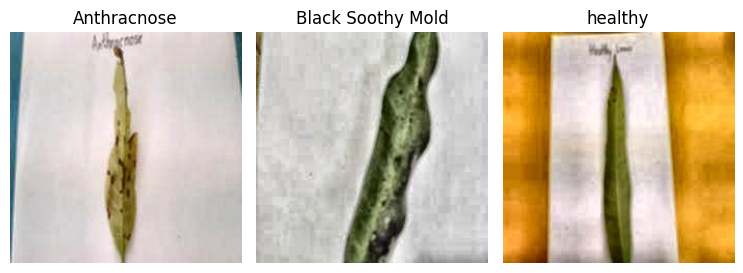

In [34]:
classes = [cls for cls in os.listdir(output_path)
           if os.path.isdir(os.path.join(output_path, cls))]

plt.figure(figsize=(10, 4))

plot_index = 1

for cls in classes:
    class_path = os.path.join(output_path, cls)
    images = os.listdir(class_path)

    if len(images) == 0:
        print(f"Skipping empty folder: {cls}")
        continue

    img_path = os.path.join(class_path, images[0])  # first image
    img = load_img(img_path)

    plt.subplot(1, len(classes), plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

    plot_index += 1

plt.tight_layout()
plt.show()


### Normalization

In [36]:
try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except:
    pass

# Input path (use resized RGB dataset)
input_path = "./dataset/daun-harumanis-kagle/grayscale_dataset"

# Output path for normalized images
output_path = "./dataset/daun-harumanis-kagle\normalized_dataset"

try:
    pillow_heif.register_heif_opener()
except:
    pass

# Input path (use resized RGB dataset)
input_path = "./dataset/daun-harumanis-kagle/grayscale_dataset"

# Output path for normalized images
output_path = "./dataset/daun-harumanis-kagle/normalized_dataset"

os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(input_path):
    cls_input = os.path.join(input_path, cls)
    cls_output = os.path.join(output_path, cls)
    
    if not os.path.isdir(cls_input):
        continue
    
    os.makedirs(cls_output, exist_ok=True)
    
    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)
        
        try:
            # Load image
            img = Image.open(img_path).convert("RGB")
            img_array = np.array(img, dtype=np.float32)
            
            # Normalize (0–1)
            img_array = img_array / 255.0
            
            # Convert back to image for saving
            img_norm = Image.fromarray((img_array * 255).astype(np.uint8))
            img_norm.save(os.path.join(cls_output, img_name))
        
        except:
            continue

print("✅ Image normalization completed successfully!")


✅ Image normalization completed successfully!


After normalization

Skipping empty folder: resized_dataset


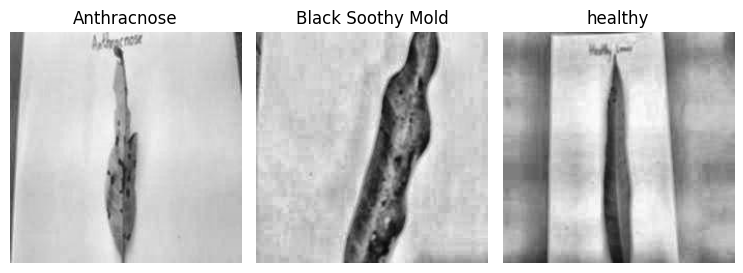

In [37]:
classes = [cls for cls in os.listdir(output_path)
           if os.path.isdir(os.path.join(output_path, cls))]

plt.figure(figsize=(10, 4))

plot_index = 1

for cls in classes:
    class_path = os.path.join(output_path, cls)
    images = os.listdir(class_path)

    if len(images) == 0:
        print(f"Skipping empty folder: {cls}")
        continue

    img_path = os.path.join(class_path, images[0])  # first image
    img = load_img(img_path)

    plt.subplot(1, len(classes), plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

    plot_index += 1

plt.tight_layout()
plt.show()


### Model Training

#### COMPLETE RESNET50 TRAINING

#### PATH & PARAMETERS

In [38]:
DATASET_PATH = "./dataset/daun-harumanis-kagle\normalized_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 40

#### DATA GENERATORS

In [40]:
datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

DATASET_PATH = "./dataset/daun-harumanis-kagle/normalized_dataset"

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 300 images belonging to 4 classes.
Found 73 images belonging to 4 classes.


LOAD RESNET50

In [41]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

CUSTOM CLASSIFIER

In [42]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


COMPILE MODEL

In [43]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#### CALLBACKS

In [44]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=4, min_lr=1e-6),
    ModelCheckpoint("best_resnet50_model.h5", save_best_only=True)
]

#### TRAINING (STAGE 1)

In [45]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.4360 - loss: 1.6174

19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5633 - loss: 1.2332 - val_accuracy: 0.6986 - val_loss: 0.7400 - learning_rate: 1.0000e-04
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.7421 - loss: 0.6829

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 946ms/step - accuracy: 0.7600 - loss: 0.6096 - val_accuracy: 0.8630 - val_loss: 0.4056 - learning_rate: 1.0000e-04
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.8557 - loss: 0.3470

19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 900ms/step - accuracy: 0.8333 - loss: 0.3915 - val_accuracy: 0.9315 - val_loss: 0.2822 - learning_rate: 1.0000e-04
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.9016 - loss: 0.3130

19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 928ms/step - accuracy: 0.9000 - loss: 0.3210 - val_accuracy: 0.9041 - val_loss: 0.2439 - learning_rate: 1.0000e-04
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.8990 - loss: 0.2702

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9033 - loss: 0.2478 - val_accuracy: 0.9452 - val_loss: 0.2122 - learning_rate: 1.0000e-04
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 984ms/step - accuracy: 0.9167 - loss: 0.2316 - val_accuracy: 0.9178 - val_loss: 0.2275 - learning_rate: 1.0000e-04
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9331 - loss: 0.2032

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9233 - loss: 0.2122 - val_accuracy: 0.9589 - val_loss: 0.1818 - learning_rate: 1.0000e-04
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.9403 - loss: 0.1719

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9533 - loss: 0.1487 - val_accuracy: 0.9863 - val_loss: 0.1129 - learning_rate: 1.0000e-04
Epoch 9/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9600 - loss: 0.1288 - val_accuracy: 0.9589 - val_loss: 0.1578 - learning_rate: 1.0000e-04
Epoch 10/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 982ms/step - accuracy: 0.9600 - loss: 0.1149 - val_accuracy: 0.9315 - val_loss: 0.1741 - learning_rate: 1.0000e-04
Epoch 11/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 976ms/step - accuracy: 0.9667 - loss: 0.0935 - val_accuracy: 0.9178 - val_loss: 0.1647 - learning_rate: 1.0000e-04
Epoch 12/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9700 - loss: 0.0992 - val_accuracy: 0.9589 - val_loss: 0.1365 - learning_rate: 1.0000e-04
Epoch 13/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 984ms/step - accuracy: 0.9733 - loss: 0.0889 - val_accuracy: 0.9452 - val_loss: 0.1462 - learning_rate: 2.0000e-05
Epoch 14/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 963ms/step - accuracy: 0.9700 -

19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9733 - loss: 0.0830 - val_accuracy: 0.9589 - val_loss: 0.1101 - learning_rate: 2.0000e-05
Epoch 17/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9767 - loss: 0.0762 - val_accuracy: 0.9589 - val_loss: 0.1326 - learning_rate: 2.0000e-05
Epoch 18/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9733 - loss: 0.0790 - val_accuracy: 0.9589 - val_loss: 0.1543 - learning_rate: 2.0000e-05
Epoch 19/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9750 - loss: 0.0640

19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9700 - loss: 0.0721 - val_accuracy: 0.9726 - val_loss: 0.0832 - learning_rate: 2.0000e-05
Epoch 20/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9767 - loss: 0.0781 - val_accuracy: 0.9726 - val_loss: 0.1349 - learning_rate: 2.0000e-05
Epoch 21/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9700 - loss: 0.0761 - val_accuracy: 0.9315 - val_loss: 0.1471 - learning_rate: 2.0000e-05
Epoch 22/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9633 - loss: 0.0885 - val_accuracy: 0.9452 - val_loss: 0.1534 - learning_rate: 2.0000e-05
Epoch 23/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9800 - loss: 0.0831 - val_accuracy: 0.9589 - val_loss: 0.1097 - learning_rate: 2.0000e-05
Epoch 24/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9867 - loss: 0.0748 - val_accuracy: 0.9178 - val_loss: 0.1755 - learning_rate: 4.0000e-06
Epoch 25/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9700 - loss: 0.08

#### FINE TUNING (STAGE 2)

In [46]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

print("✅ ResNet50 Training & Fine-tuning Completed Successfully")

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7533 - loss: 0.7547 - val_accuracy: 0.9452 - val_loss: 0.1481 - learning_rate: 1.0000e-05
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8800 - loss: 0.3156 - val_accuracy: 0.9041 - val_loss: 0.2462 - learning_rate: 1.0000e-05
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9167 - loss: 0.2249 - val_accuracy: 0.9041 - val_loss: 0.2097 - learning_rate: 1.0000e-05
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9567 - loss: 0.1337 - val_accuracy: 0.8904 - val_loss: 0.2528 - learning_rate: 1.0000e-05
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9600 - loss: 0.1455 - val_accuracy: 0.9041 - val_loss: 0.2388 - learning_rate: 2.0000e-06
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9633 - loss: 0.1258 - val_accuracy: 0.9178 - val_loss: 0.2340 - learning_rate: 2.0000e-06
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9767 - loss:

# Model Saving

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

classes = ['Anthracnose','Black Soothy Mold','healthy']
num_classes = len(classes)

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
# define generators
train_datagen= ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    './dataset/daun-harumanis-kagle',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    './dataset/daun-harumanis-kagle',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
dataset_path = "./dataset/daun-harumanis-kagle/normalized_dataset"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Found 2611 images belonging to 9 classes.
Found 2611 images belonging to 9 classes.
Found 300 images belonging to 4 classes.
Found 73 images belonging to 4 classes.
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.7967 - loss: 0.6049 - val_accuracy: 0.4932 - val_loss: 504.2023
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.9367 - loss: 0.2576 - val_accuracy: 0.4932 - val_loss: 784.3711
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.9067 - loss: 0.3279 - val_accuracy: 0.4932 - val_loss: 709.4178
Epoch 4/10
 5/19 ━━━━━━━━━━━━━━━━━━━━ 1:01 4s/step - accuracy: 0.8827 - loss: 0.7822

In [ ]:
# Save the trained model
model.save("crop_disease_model.h5")

print("Model saved successfully as crop_disease_model.h5")